# Predictive Maintenance — AI4I 2020 Dataset



---
## Imports

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Plot settings
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

# Project root (works regardless of kernel CWD)
PROJECT_DIR = r'd:\Project\Predictive Maintenance'
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('All imports loaded successfully.')

All imports loaded successfully.


---
## Part 1 — Dataset Handling
**Objective:** Load, inspect, and understand the AI4I 2020 Predictive Maintenance dataset.

### Step 1 — Load the dataset

In [10]:
csv_path = os.path.join(PROJECT_DIR, 'data', 'ai4i2020.csv')
df = pd.read_csv(csv_path)
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

SyntaxError: unexpected character after line continuation character (24146003.py, line 2)

### Step 2 — Inspect the dataset

In [ ]:
# First 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [ ]:
# Check for missing values
null_counts = df.isnull().sum()
print(null_counts)
print(f'\nTotal nulls: {null_counts.sum()}')

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Total nulls: 0


### Step 3 — Basic statistics

In [ ]:
# Summary statistics for numeric columns
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [ ]:
# Target variable distribution
counts = df['Machine failure'].value_counts()
total = len(df)
for label, count in counts.items():
    tag = 'Failure' if label == 1 else 'No Failure'
    print(f'  {label} ({tag:>10}): {count:>6,}  ({count / total * 100:.2f}%)')

  0 (No Failure):  9,661  (96.61%)
  1 (   Failure):    339  (3.39%)


---
## Part 2 — Data Preprocessing
**Objective:** Clean and prepare the dataset for model training.

### Step 1 — Remove unnecessary columns

In [ ]:
# Work on a copy to preserve the original for EDA
df_clean = df.copy()

# Drop identifier columns (no predictive value)
columns_to_drop = ['UDI', 'Product ID']
df_clean.drop(columns=columns_to_drop, inplace=True)
print(f'Dropped identifiers: {columns_to_drop}')

# Drop individual failure-type flags (target leakage)
leakage_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_clean.drop(columns=leakage_cols, inplace=True)
print(f'Dropped leakage cols: {leakage_cols}')
print(f'Remaining columns: {list(df_clean.columns)}')

Dropped identifiers: ['UDI', 'Product ID']
Dropped leakage cols: ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
Remaining columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']


### Step 2 — Handle missing values

In [ ]:
before = len(df_clean)
df_clean.dropna(inplace=True)  # dataset has 0 nulls, but defensive coding
after = len(df_clean)
print(f'Rows before: {before:,} | Rows after: {after:,} | Dropped: {before - after}')

Rows before: 10,000 | Rows after: 10,000 | Dropped: 0


### Step 3 — Encode categorical variables

In [ ]:
le = LabelEncoder()
df_clean['Type'] = le.fit_transform(df_clean['Type'])  # H=0, L=1, M=2
print(f'Classes: {list(le.classes_)}  ->  {list(le.transform(le.classes_))}')
df_clean.head()

Classes: ['H', 'L', 'M']  ->  [np.int64(0), np.int64(1), np.int64(2)]


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


### Step 4 — Feature selection

In [ ]:
feature_columns = [
    'Type',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df_clean[feature_columns]
y = df_clean['Machine failure']

print(f'X shape: {X.shape}  |  y shape: {y.shape}')
print(f'\nTarget distribution:\n{y.value_counts()}')

X shape: (10000, 6)  |  y shape: (10000,)

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


### Step 5 — Feature scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Scaled X mean (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Scaled X std  (should be ~1): {X_scaled.std(axis=0).round(4)}')
print('\nPreprocessing complete.')

Scaled X mean (should be ~0): [-0. -0.  0. -0.  0.  0.]
Scaled X std  (should be ~1): [1. 1. 1. 1. 1. 1.]

Preprocessing complete.


---
## Part 3 — Exploratory Data Analysis (EDA)
**Objective:** Visualize the dataset to uncover patterns, correlations, and class distribution.

### Step 1 — Feature distribution plots

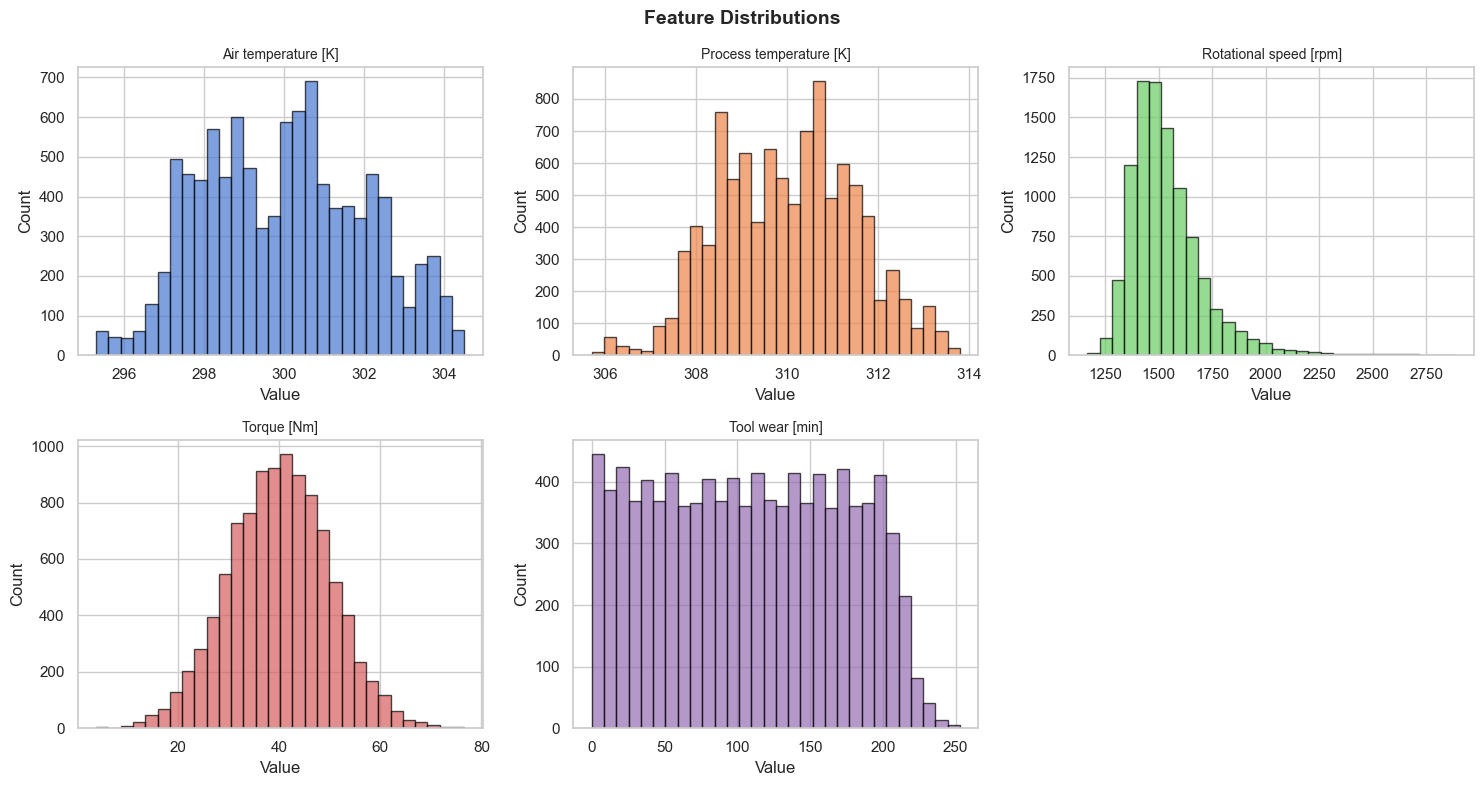

In [ ]:
numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7,
            color=sns.color_palette('muted')[i])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

**Insights:** Shows if features are normally distributed, skewed, or have outliers.

### Step 2 — Correlation heatmap

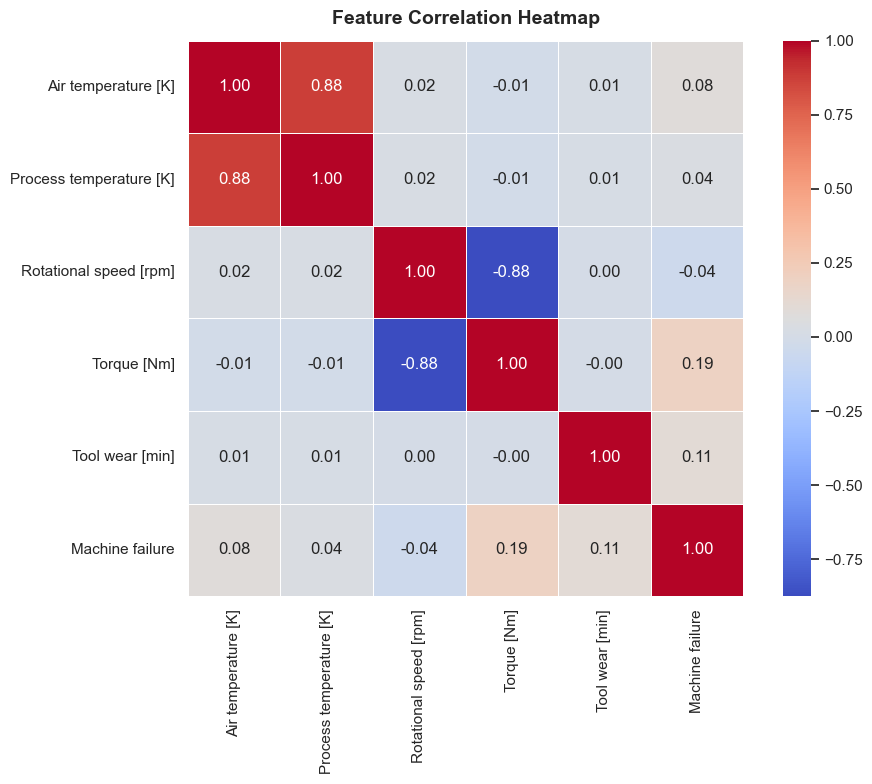

In [ ]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols + ['Machine failure']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

**Insights:** Reveals multicollinearity (e.g., Torque vs Rotational Speed are often inversely correlated) and feature-target relationships.

### Step 3 — Failure analysis

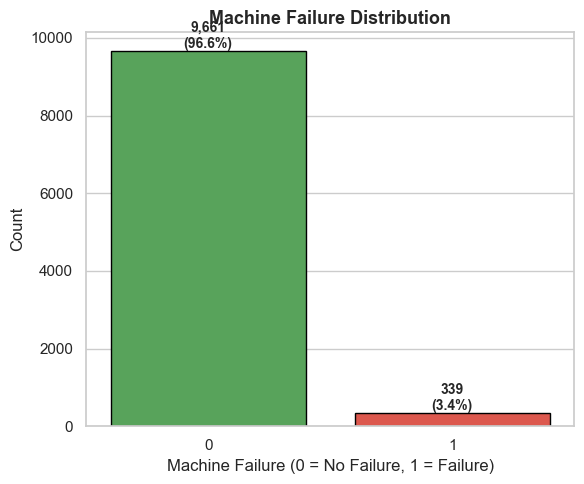

In [ ]:
# Count plot: failure vs non-failure
fig, ax = plt.subplots(figsize=(6, 5))
palette = {'0': '#4caf50', '1': '#f44336'}
plot_df = df.copy()
plot_df['Machine failure'] = plot_df['Machine failure'].astype(str)

sns.countplot(x='Machine failure', data=plot_df, hue='Machine failure',
              palette=palette, ax=ax, edgecolor='black', legend=False)
ax.set_title('Machine Failure Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Machine Failure (0 = No Failure, 1 = Failure)')
ax.set_ylabel('Count')

# Annotate bars
total = len(plot_df)
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count:,}\n({count/total*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'failure_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

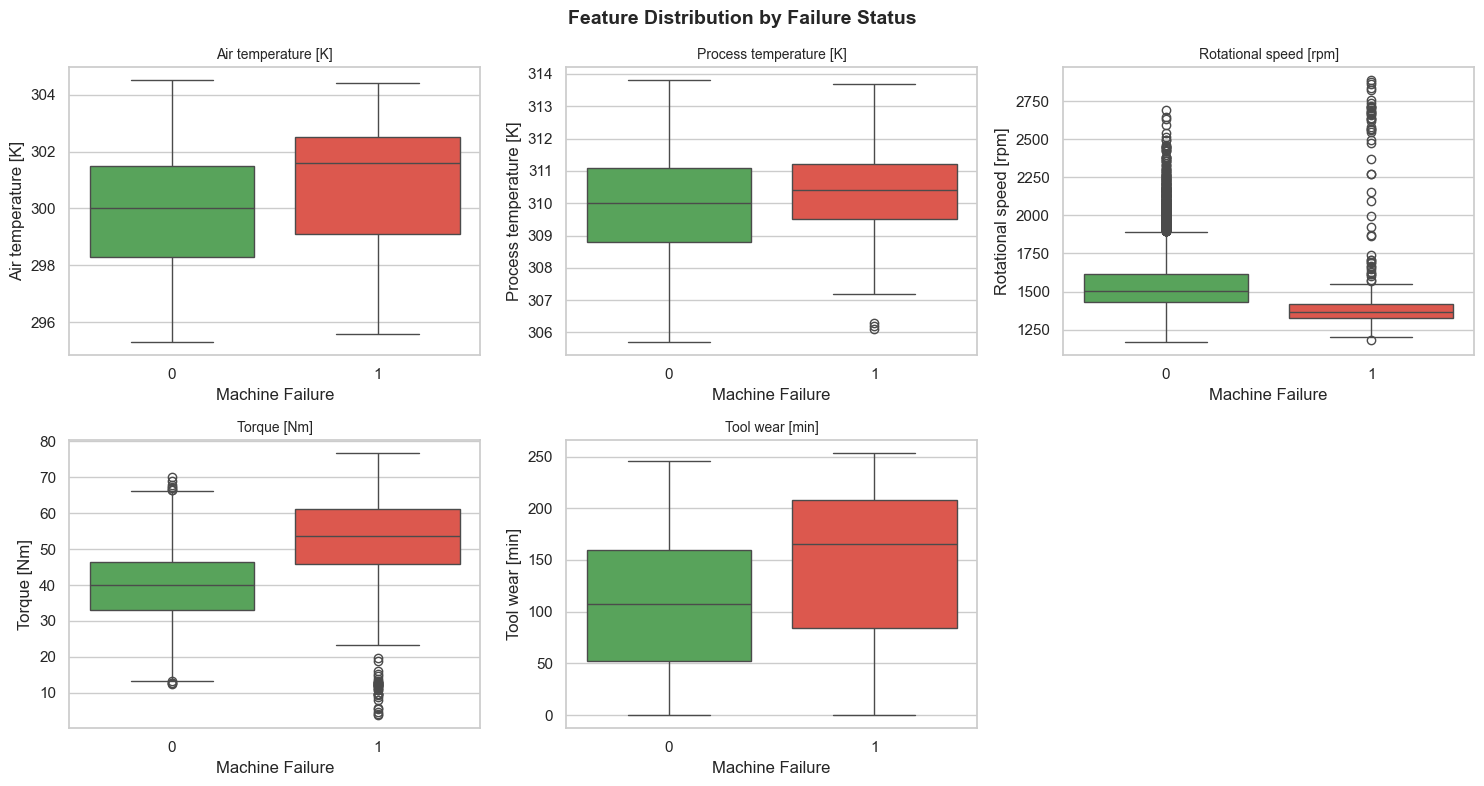

In [ ]:
# Box plots: feature values grouped by failure
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Feature Distribution by Failure Status', fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(x='Machine failure', y=col, data=plot_df,
                hue='Machine failure', palette=palette,
                ax=ax, legend=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Machine Failure')

axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'failure_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

**Insights:** Highlights which features differ most between failure and non-failure groups (e.g., higher torque leads to more failures).

---
## Part 4 — Machine Learning Model Training
**Objective:** Train a Random Forest classifier to predict machine failure, evaluate its performance, and visualize feature importance.

### Step 1 — Train / Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train failure rate: {y_train.mean():.4f}  |  Test failure rate: {y_test.mean():.4f}')

Train: (8000, 6)  |  Test: (2000, 6)
Train failure rate: 0.0339  |  Test failure rate: 0.0340


### Step 2 — Train the model

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'   # handles class imbalance
)
model.fit(X_train, y_train)
print('Training complete.')

Training complete.


### Step 3 — Make predictions

In [ ]:
y_pred = model.predict(X_test)

### Step 4 — Accuracy score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9805


### Step 5 — Classification report & Confusion matrix

In [ ]:
print(classification_report(y_test, y_pred, target_names=['No Failure', 'Failure']))

              precision    recall  f1-score   support

  No Failure       0.98      1.00      0.99      1932
     Failure       0.87      0.50      0.64        68

    accuracy                           0.98      2000
   macro avg       0.93      0.75      0.81      2000
weighted avg       0.98      0.98      0.98      2000



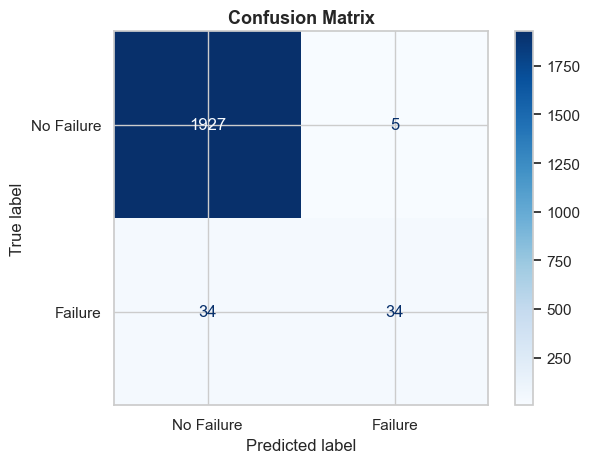

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

### Step 6 — Feature importance

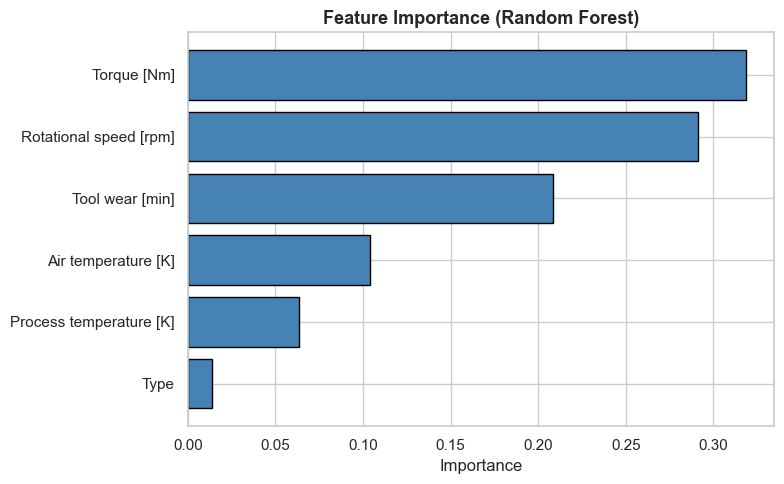


Feature Importance (ranked):
  Torque [Nm]                    : 0.3187
  Rotational speed [rpm]         : 0.2914
  Tool wear [min]                : 0.2086
  Air temperature [K]            : 0.1040
  Process temperature [K]        : 0.0635
  Type                           : 0.0139


In [ ]:
importances = model.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh([feature_columns[i] for i in sorted_idx],
         importances[sorted_idx],
         color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print ranked
print('\nFeature Importance (ranked):')
for i in reversed(sorted_idx):
    print(f'  {feature_columns[i]:30s} : {importances[i]:.4f}')

---
## Summary

| Part | What was done |
|---|---|
| **Part 1** | Loaded 10,000 rows x 14 columns, confirmed 0 nulls |
| **Part 2** | Dropped identifiers + leakage cols, encoded `Type`, scaled features |
| **Part 3** | Plotted distributions, correlation heatmap, and failure analysis |
| **Part 4** | Trained Random Forest (balanced), evaluated accuracy, confusion matrix, feature importance |

All plots saved to `outputs/` folder.